In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
dataset = pd.read_csv('/content/supercomputerpowerflops new.csv')

In [4]:
dataset

,country,Codes,Years,Floating-Point Operations per Second (GFLOPS)
0,World,OWID_WRL,1993,124
1,World,OWID_WRL,1994,170
2,World,OWID_WRL,1995,170
3,World,OWID_WRL,1996,368
4,World,OWID_WRL,1997,1300
5,World,OWID_WRL,1998,1300
6,World,OWID_WRL,1999,2400
7,World,OWID_WRL,2000,4900
8,World,OWID_WRL,2001,7200
9,World,OWID_WRL,2002,35900


In [5]:
x = dataset.Years
y = dataset['Floating-Point Operations per Second (GFLOPS)']

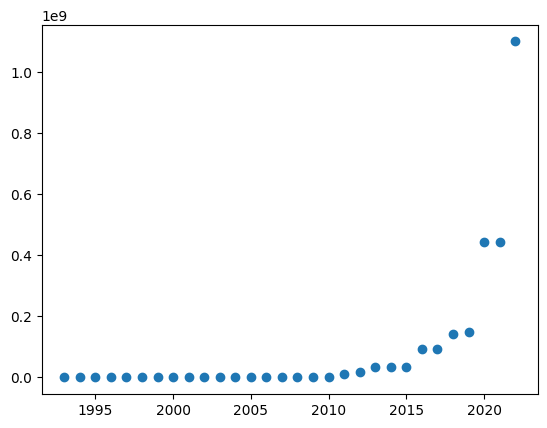

In [12]:
plt.scatter(x, y)

In [13]:
y = np.log(y)

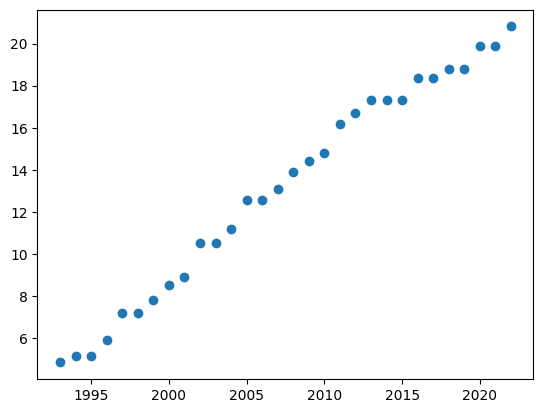

In [14]:
plt.scatter(x,y)

In [17]:
x = x - x.mean()

In [18]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [27]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1, activation=None)
])

In [28]:
def schedule(epoch, lr):
  if epoch < 50:
    return 0.0001
  return 0.001

scheduler = tf.keras.callbacks.LearningRateScheduler(schedule)

In [29]:
model.compile(optimizer=tf.keras.optimizers.SGD(0.001, 0.9),
              loss = 'mse',)

In [30]:
r = model.fit(xtrain, ytrain, validation_data=(xtest, ytest), epochs=200, callbacks = [scheduler])

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step - loss: 182.7614 - val_loss: 209.3876 - learning_rate: 1.0000e-04
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 178.5325 - val_loss: 201.3040 - learning_rate: 1.0000e-04
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 170.7311 - val_loss: 190.2928 - learning_rate: 1.0000e-04
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 160.1519 - val_loss: 177.0994 - learning_rate: 1.0000e-04
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 147.5548 - val_loss: 162.5035 - learning_rate: 1.0000e-04
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 133.7371 - val_loss: 147.2535 - learning_rate: 1.0000e-04
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 119.4592 - val_loss: 131.9663 - learning_rate: 1.0000e-04
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 105.3214 - val_loss: 117.6050 - learning_rate: 1.0000e-04
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 92.2356 - val

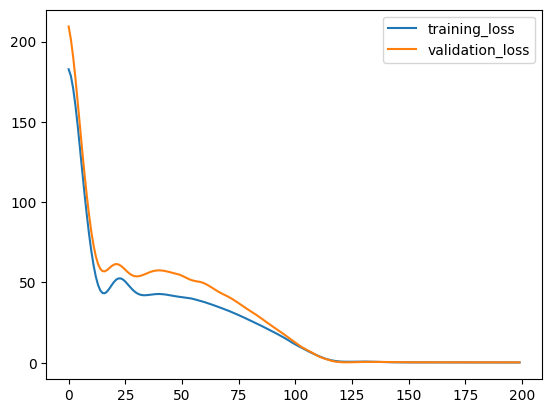

In [31]:
plt.plot(r.history['loss'], label = 'training_loss')
plt.plot(r.history['val_loss'], label = 'validation_loss')
plt.legend()